# DO Classifier Test Notebook

Run the DO scene segmenter, crop detected cards, classify each crop with the DO full-card classifier, and group predictions using the fixed UNO table geometry (`p1` bottom, `p2` right, `p3` top, `p4` left, center in the middle).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from matplotlib.patches import Rectangle
from PIL import Image
from skimage.feature import hog as skimage_hog

PROJECT_ROOT = Path.cwd().resolve()
while not ((PROJECT_ROOT / "project" / "training_data").exists() and (PROJECT_ROOT / "data").exists()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not locate workspace root containing project/training_data and data/.")
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_DIR = PROJECT_ROOT / "project"
TRAINING_DATA = PROJECT_DIR / "training_data"
MODELS_DIR = PROJECT_DIR / "models"
CHALLENGE_DIR = PROJECT_ROOT / "data" / "iapr-26-uno-vision-challenge"

SCENE_LABELS_PATH = TRAINING_DATA / "object_labels" / "augmented_scenes" / "labels.json"
TRAIN_IMAGES_DIR = CHALLENGE_DIR / "train_images"
TEST_IMAGES_DIR = CHALLENGE_DIR / "test_images"

SEG_MODEL_PATH = MODELS_DIR / "scene_segmenter_unet_small.pth"
CARD_CLF_PATH = MODELS_DIR / "card_clf_do.pkl"
CARD_CLASSES_PATH = MODELS_DIR / "card_classes_do.npy"

# Options: "augmented_scene", "train_image", or "test_image".
# Use augmented_scene first because it has labels.json for a quick sanity check.
IMAGE_SOURCE = "augmented_scene"
IMAGE_INDEX = 0
IMAGE_ID = None

print(f"Project root: {PROJECT_ROOT}")
print(f"Segmenter:    {SEG_MODEL_PATH}")
print(f"Classifier:   {CARD_CLF_PATH}")
print(f"Classes:      {CARD_CLASSES_PATH}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Segmenter:    C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\scene_segmenter_unet_small.pth
Classifier:   C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_clf_do.pkl
Classes:      C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_classes_do.npy


## Shared Helpers

In [2]:
IMG_SIZE_CLASSIFIER = 128
IMG_SIZE_SEGMENTER = 256
FOURIER_COEFFS = 32
REGION_COLORS = {
    "center": "gold",
    "p1": "tab:blue",
    "p2": "tab:green",
    "p3": "tab:red",
    "p4": "tab:purple",
}


def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(path_value)
    return path if path.is_absolute() else PROJECT_ROOT / path


def letterbox_cv2(img_bgr: np.ndarray, size: int = IMG_SIZE_CLASSIFIER, fill: int = 128) -> np.ndarray:
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), fill, dtype=np.uint8)
    y0 = (size - new_h) // 2
    x0 = (size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas


def extract_color_feat(img_bgr: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    saturated = ((hsv[:, :, 1] > 35) & (hsv[:, :, 2] > 40)).astype(np.uint8) * 255
    if int(saturated.sum()) == 0:
        saturated = None
    h_hist = cv2.calcHist([hsv], [0], saturated, [36], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], saturated, [16], [0, 256]).flatten()
    v_hist = cv2.calcHist([hsv], [2], saturated, [8], [0, 256]).flatten()
    feat = np.concatenate([h_hist, s_hist, v_hist]).astype(np.float32)
    return feat / (feat.sum() + 1e-6)


def extract_hog_feat(img_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    ).astype(np.float32)


def extract_fourier_feat(img_bgr: np.ndarray, n_coeffs: int = FOURIER_COEFFS) -> np.ndarray:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    border = 8
    bw[:border, :] = 0
    bw[-border:, :] = 0
    bw[:, :border] = 0
    bw[:, -border:] = 0

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros(n_coeffs, dtype=np.float32)

    contour = max(contours, key=cv2.contourArea)
    pts = contour[:, 0, :].astype(np.float32)
    if len(pts) < max(10, n_coeffs + 1):
        return np.zeros(n_coeffs, dtype=np.float32)

    z = pts[:, 0] + 1j * pts[:, 1]
    z = z - np.mean(z)
    magnitude = np.abs(np.fft.fft(z))[1:n_coeffs + 1]
    if len(magnitude) < n_coeffs:
        magnitude = np.pad(magnitude, (0, n_coeffs - len(magnitude)))
    magnitude = magnitude / (magnitude[0] + 1e-6)
    return magnitude.astype(np.float32)


def extract_features(img_bgr: np.ndarray) -> np.ndarray:
    img_lb = letterbox_cv2(img_bgr)
    return np.concatenate([
        extract_color_feat(img_lb),
        extract_hog_feat(img_lb),
        extract_fourier_feat(img_lb),
    ]).astype(np.float32)


def crop_with_margin(img_bgr: np.ndarray, box: tuple[int, int, int, int], margin_fraction: float = 0.08) -> np.ndarray:
    x0, y0, x1, y1 = map(int, box)
    h, w = img_bgr.shape[:2]
    bw = max(1, x1 - x0)
    bh = max(1, y1 - y0)
    margin = int(round(margin_fraction * max(bw, bh)))
    x0 = max(0, x0 - margin)
    y0 = max(0, y0 - margin)
    x1 = min(w, x1 + margin)
    y1 = min(h, y1 + margin)
    return img_bgr[y0:y1, x0:x1]


def box_iou(a: tuple[int, int, int, int], b: tuple[int, int, int, int]) -> float:
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    ix0, iy0 = max(ax0, bx0), max(ay0, by0)
    ix1, iy1 = min(ax1, bx1), min(ay1, by1)
    iw, ih = max(0, ix1 - ix0), max(0, iy1 - iy0)
    inter = iw * ih
    area_a = max(0, ax1 - ax0) * max(0, ay1 - ay0)
    area_b = max(0, bx1 - bx0) * max(0, by1 - by0)
    return inter / max(1, area_a + area_b - inter)


def nms_boxes(boxes: list[tuple[int, int, int, int]], iou_threshold: float = 0.35) -> list[tuple[int, int, int, int]]:
    boxes = sorted(boxes, key=lambda box: (box[2] - box[0]) * (box[3] - box[1]), reverse=True)
    kept: list[tuple[int, int, int, int]] = []
    for box in boxes:
        if all(box_iou(box, kept_box) < iou_threshold for kept_box in kept):
            kept.append(box)
    return kept


def assign_region(box: tuple[int, int, int, int], image_width: int, image_height: int) -> str:
    x0, y0, x1, y1 = box
    cx = ((x0 + x1) / 2) / image_width
    cy = ((y0 + y1) / 2) / image_height

    if 0.36 <= cx <= 0.64 and 0.30 <= cy <= 0.70:
        return "center"

    distances = {
        "p1": abs(1.00 - cy) + 0.25 * abs(cx - 0.50),
        "p2": abs(1.00 - cx) + 0.25 * abs(cy - 0.50),
        "p3": abs(0.00 - cy) + 0.25 * abs(cx - 0.50),
        "p4": abs(0.00 - cx) + 0.25 * abs(cy - 0.50),
    }
    return min(distances, key=distances.get)


def format_cards(cards: list[str]) -> str:
    return "EMPTY" if len(cards) == 0 else ";".join(cards)


print("Shared helpers ready.")

Shared helpers ready.


## Segmenter Helpers

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return self.out(d1)


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def letterbox_pil_with_meta(img_pil: Image.Image, target_size: int = IMG_SIZE_SEGMENTER, fill: int = 255):
    w, h = img_pil.size
    scale = min(target_size / w, target_size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = img_pil.resize((new_w, new_h), Image.BILINEAR)

    pad_w = target_size - new_w
    pad_h = target_size - new_h
    left = pad_w // 2
    top = pad_h // 2
    right = pad_w - left
    bottom = pad_h - top

    img_lb = TF.pad(resized, (left, top, right, bottom), fill=fill)
    meta = {"orig_w": w, "orig_h": h, "new_w": new_w, "new_h": new_h, "left": left, "top": top}
    return img_lb, meta


def unletterbox_probability(prob_lb: np.ndarray, meta: dict[str, int]) -> np.ndarray:
    left, top = meta["left"], meta["top"]
    new_w, new_h = meta["new_w"], meta["new_h"]
    orig_w, orig_h = meta["orig_w"], meta["orig_h"]
    core = prob_lb[top:top + new_h, left:left + new_w]
    return cv2.resize(core, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)


def segment_image(img_bgr: np.ndarray, model: nn.Module, device: torch.device) -> np.ndarray:
    img_pil = Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    img_lb, meta = letterbox_pil_with_meta(img_pil)
    x = TF.to_tensor(img_lb)
    x = TF.normalize(x, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        prob_lb = torch.sigmoid(logits)[0, 0].cpu().numpy()

    return unletterbox_probability(prob_lb, meta)


def split_touching_component(component_mask: np.ndarray, min_area: int, max_instances: int = 8) -> list[np.ndarray]:
    """Try to split one connected blob into multiple card candidates."""
    component = (component_mask > 0).astype(np.uint8)
    component_area = int(np.count_nonzero(component))
    if component_area < 2 * min_area:
        return [component]

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    seed_min_area = max(25, min_area // 5)

    for erode_iters in (1, 2, 3, 4):
        eroded = cv2.erode(component, kernel, iterations=erode_iters)
        n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(eroded, connectivity=8)
        if n_labels <= 2:
            continue

        candidate_parts: list[np.ndarray] = []
        for label_idx in range(1, n_labels):
            seed_area = int(stats[label_idx, cv2.CC_STAT_AREA])
            if seed_area < seed_min_area:
                continue
            seed = (labels == label_idx).astype(np.uint8)
            grown = cv2.dilate(seed, kernel, iterations=erode_iters)
            grown = ((grown > 0) & (component > 0)).astype(np.uint8)
            if int(np.count_nonzero(grown)) >= min_area:
                candidate_parts.append(grown)

        if len(candidate_parts) < 2:
            continue

        candidate_parts = sorted(candidate_parts, key=lambda part: int(np.count_nonzero(part)), reverse=True)
        accepted_parts: list[np.ndarray] = []
        occupied = np.zeros_like(component, dtype=np.uint8)

        for part in candidate_parts:
            unique = ((part > 0) & (occupied == 0)).astype(np.uint8)
            if int(np.count_nonzero(unique)) >= min_area:
                accepted_parts.append(unique)
                occupied[unique > 0] = 1
            if len(accepted_parts) >= max_instances:
                break

        if len(accepted_parts) >= 2:
            return accepted_parts

    return [component]


def boxes_from_probability(probability: np.ndarray, threshold: float = 0.50, max_components: int = 40) -> tuple[list[tuple[int, int, int, int]], np.ndarray]:
    h, w = probability.shape[:2]
    mask = (probability > threshold).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    min_area = max(400, int(0.00035 * h * w))
    min_split_area = max(220, int(0.55 * min_area))
    boxes: list[tuple[int, int, int, int]] = []

    for label_idx in range(1, n_labels):
        component_area = int(stats[label_idx, cv2.CC_STAT_AREA])
        if component_area < min_area:
            continue

        component_mask = (labels == label_idx).astype(np.uint8)
        candidate_parts = split_touching_component(component_mask, min_split_area)

        for part_mask in candidate_parts:
            ys, xs = np.where(part_mask > 0)
            if ys.size == 0:
                continue

            x0, x1 = int(xs.min()), int(xs.max() + 1)
            y0, y1 = int(ys.min()), int(ys.max() + 1)
            bw = x1 - x0
            bh = y1 - y0
            area = int(np.count_nonzero(part_mask))
            aspect = bw / max(1, bh)

            if area >= min_split_area and 0.12 <= aspect <= 5.0:
                boxes.append((x0, y0, x1, y1))

    boxes = nms_boxes(boxes)[:max_components]
    return boxes, mask


print("Segmenter helpers ready.")

Segmenter helpers ready.


## Load Models And Pick An Image

In [4]:
for model_path in (SEG_MODEL_PATH, CARD_CLF_PATH, CARD_CLASSES_PATH):
    if not model_path.is_file():
        raise FileNotFoundError(f"Missing model file: {model_path}. Run the DO training notebooks first.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
segmenter = UNetSmall().to(device)
n_params = count_trainable_params(segmenter)
assert n_params <= 12_000_000, f"Segmenter has {n_params:,} trainable params, exceeds 12M cap."
print(f"[compliance] UNetSmall: {n_params:,} trainable params")

segmenter.load_state_dict(torch.load(str(SEG_MODEL_PATH), map_location=device))
segmenter.eval()

card_clf = joblib.load(CARD_CLF_PATH)
card_classes = np.load(CARD_CLASSES_PATH, allow_pickle=True)
print(f"Loaded card classifier with {len(card_classes)} classes.")
print(f"Device: {device}")

[compliance] UNetSmall: 1,928,417 trainable params
Loaded card classifier with 53 classes.
Device: cuda


In [5]:
scene_truth = None

if IMAGE_SOURCE == "augmented_scene":
    if not SCENE_LABELS_PATH.is_file():
        raise FileNotFoundError(f"No augmented-scene metadata found: {SCENE_LABELS_PATH}")
    with SCENE_LABELS_PATH.open("r", encoding="utf-8") as labels_file:
        all_scene_labels = json.load(labels_file)
    scene_truth = all_scene_labels[IMAGE_INDEX]
    image_path = resolve_project_path(scene_truth["image_path"])
    image_id = scene_truth["scene"]
elif IMAGE_SOURCE == "train_image":
    image_paths = sorted(TRAIN_IMAGES_DIR.glob("*.jpg"))
    if IMAGE_ID is not None:
        image_paths = [path for path in image_paths if path.stem == IMAGE_ID]
    image_path = image_paths[IMAGE_INDEX]
    image_id = image_path.stem
elif IMAGE_SOURCE == "test_image":
    image_paths = sorted(TEST_IMAGES_DIR.glob("*.jpg"))
    if IMAGE_ID is not None:
        image_paths = [path for path in image_paths if path.stem == IMAGE_ID]
    image_path = image_paths[IMAGE_INDEX]
    image_id = image_path.stem
else:
    raise ValueError(f"Unknown IMAGE_SOURCE: {IMAGE_SOURCE}")

img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Cannot read image: {image_path}")

H, W = img_bgr.shape[:2]
print(f"Image source: {IMAGE_SOURCE}")
print(f"Image id:     {image_id}")
print(f"Image path:   {image_path}")
print(f"Image shape:  {W} x {H}")
if scene_truth is not None:
    print(f"Truth cards:  {len(scene_truth.get('cards', []))}")
    print(f"Truth active player: {scene_truth.get('active_player')}")

Image source: augmented_scene
Image id:     aug_scene_00000
Image path:   C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\training_images\augmented_scenes\aug_scene_00000.jpg
Image shape:  1280 x 720
Truth cards:  13
Truth active player: p2


## Segment Cards

Detected boxes: 13
Foreground pixels: 147439


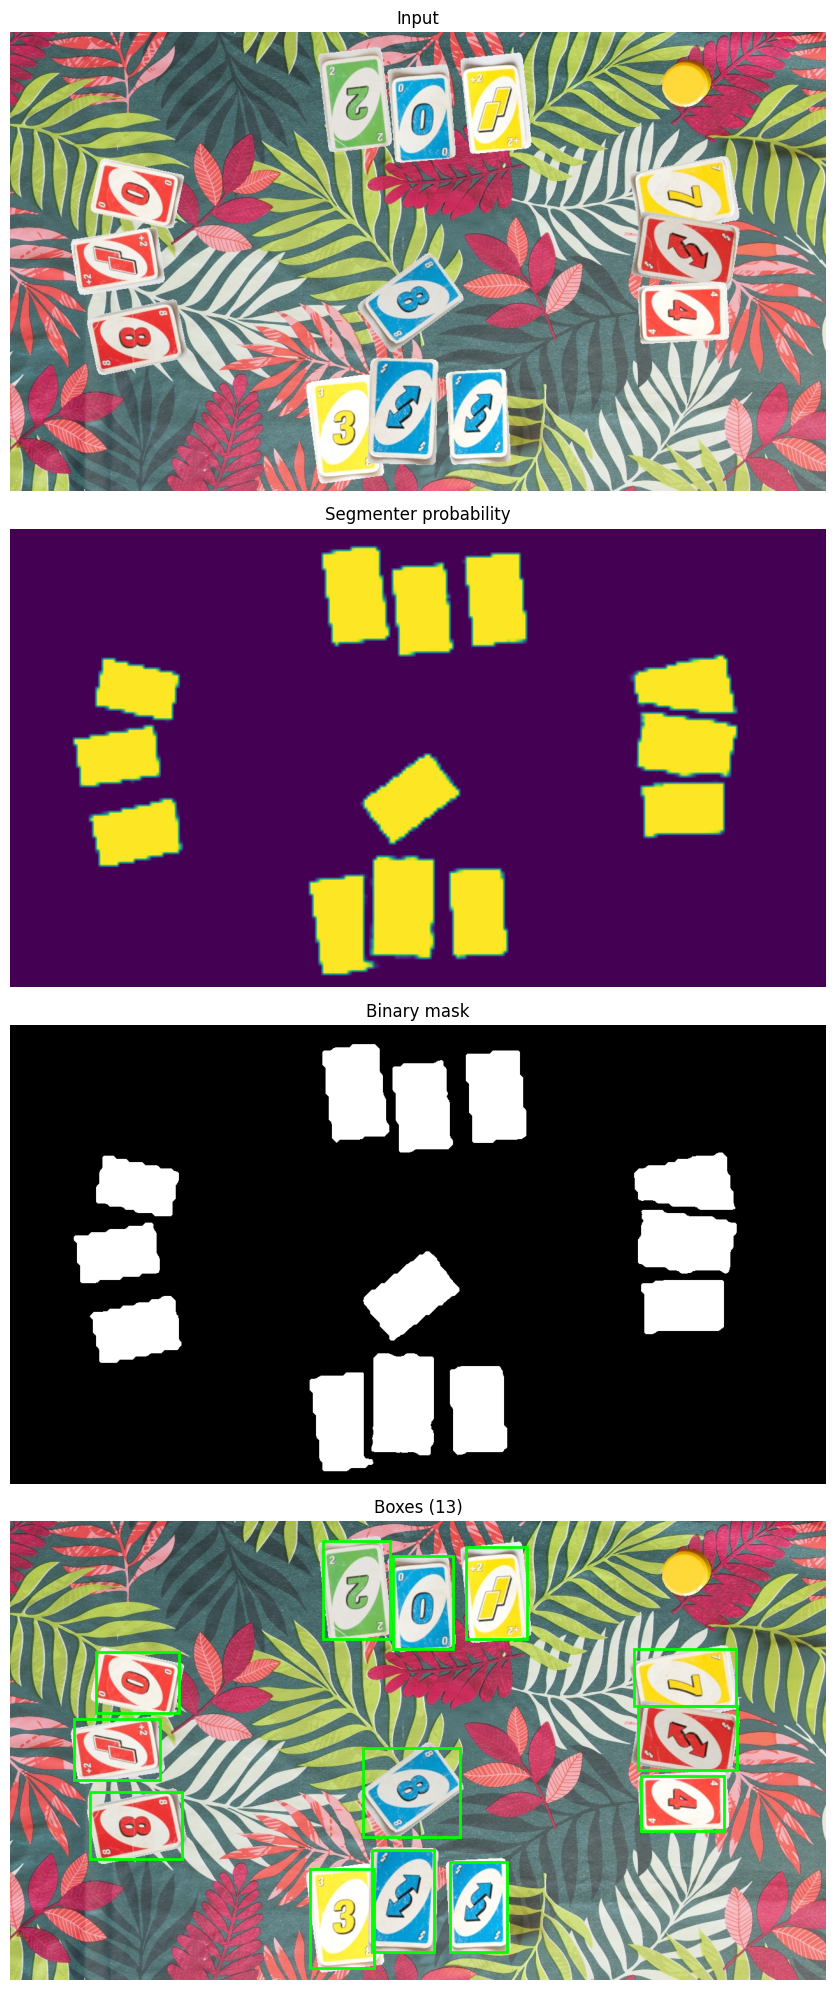

In [6]:
global_prob = segment_image(img_bgr, segmenter, device)
boxes, mask_bin = boxes_from_probability(global_prob, threshold=0.50)

print(f"Detected boxes: {len(boxes)}")
print(f"Foreground pixels: {int(mask_bin.sum())}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
fig, axes = plt.subplots(4, 1, figsize=(22, 20))
axes[0].imshow(img_rgb)
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(global_prob, cmap="viridis")
axes[1].set_title("Segmenter probability")
axes[1].axis("off")

axes[2].imshow(mask_bin, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Binary mask")
axes[2].axis("off")

axes[3].imshow(img_rgb)
for x0, y0, x1, y1 in boxes:
    axes[3].add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=2))
axes[3].set_title(f"Boxes ({len(boxes)})")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Classify And Group By Table Geometry

Predictions:
  box 00 (554, 355, 705, 495) -> b_8 [center] conf=0.19
  box 01 (490, 30, 595, 185) -> g_2 [p3] conf=0.41
  box 02 (567, 515, 665, 675) -> b_reverse [p1] conf=0.66
  box 03 (985, 290, 1140, 390) -> r_reverse [p2] conf=0.35
  box 04 (470, 545, 570, 700) -> y_3 [p1] conf=0.18
  box 05 (125, 425, 269, 530) -> r_8 [p4] conf=0.19
  box 06 (979, 200, 1138, 290) -> y_7 [p2] conf=0.07
  box 07 (715, 40, 810, 185) -> y_draw_2 [p3] conf=0.40
  box 08 (600, 55, 695, 200) -> b_0 [p3] conf=0.26
  box 09 (100, 310, 235, 405) -> r_draw_2 [p4] conf=0.56
  box 10 (690, 535, 780, 675) -> b_reverse [p1] conf=0.63
  box 11 (135, 205, 265, 300) -> r_0 [p4] conf=0.19
  box 12 (990, 400, 1120, 485) -> r_4 [p2] conf=0.24


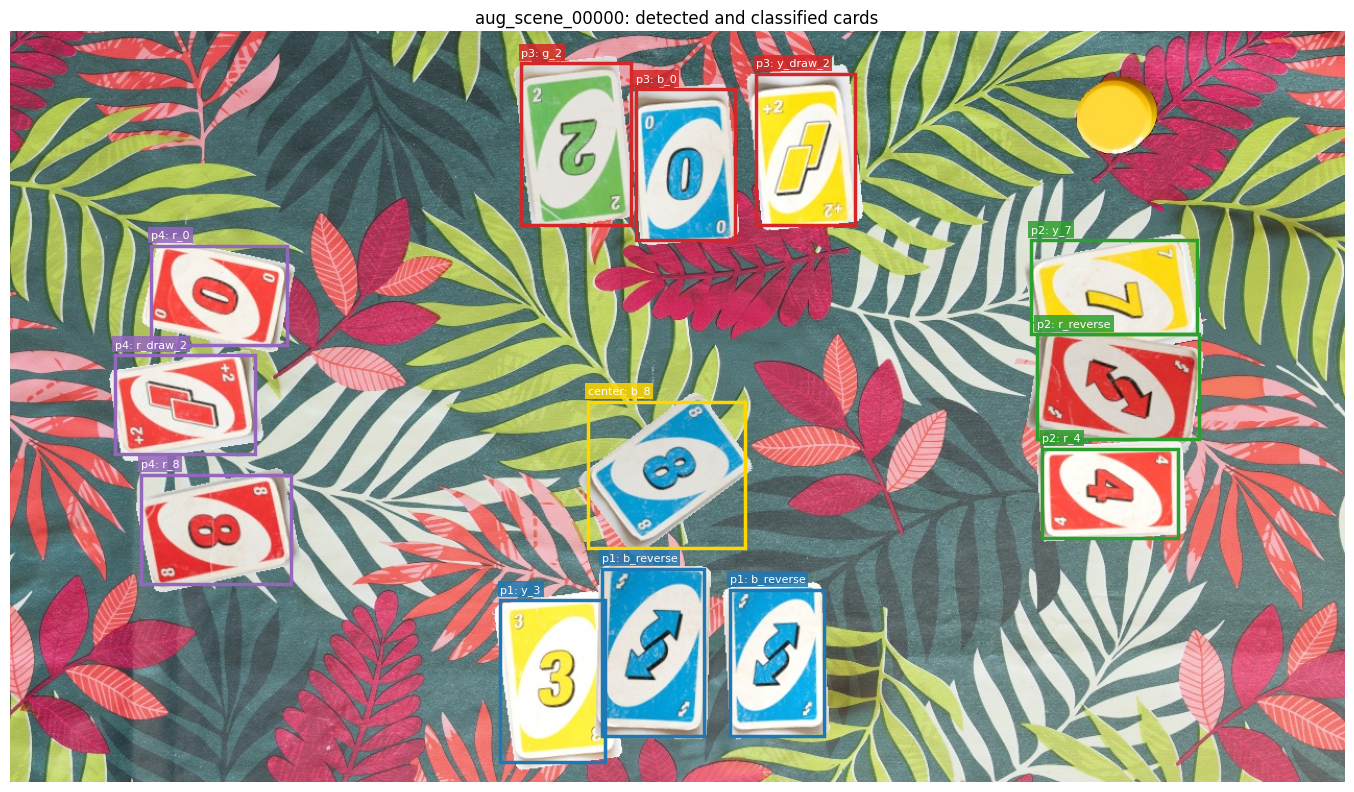

In [7]:
pred_rows: list[dict[str, object]] = []

for box_index, box in enumerate(boxes):
    crop_bgr = crop_with_margin(img_bgr, box)
    feature = extract_features(crop_bgr).reshape(1, -1)
    pred_index = int(card_clf.predict(feature)[0])
    label = str(card_classes[pred_index])

    confidence = None
    if hasattr(card_clf, "predict_proba"):
        confidence = float(np.max(card_clf.predict_proba(feature)))

    region = assign_region(box, W, H)
    pred_rows.append({
        "box_index": box_index,
        "box": box,
        "label": label,
        "confidence": confidence,
        "region": region,
    })

print("Predictions:")
for row in pred_rows:
    conf = "" if row["confidence"] is None else f" conf={row['confidence']:.2f}"
    print(f"  box {row['box_index']:02d} {row['box']} -> {row['label']} [{row['region']}]{conf}")

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(img_rgb)
for row in pred_rows:
    x0, y0, x1, y1 = row["box"]
    region = str(row["region"])
    color = REGION_COLORS.get(region, "white")
    text = f"{region}: {row['label']}"
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=color, linewidth=2.5))
    ax.text(
        x0,
        max(0, y0 - 8),
        text,
        color="white",
        fontsize=8,
        bbox={"facecolor": color, "alpha": 0.85, "pad": 2, "edgecolor": "none"},
    )
ax.set_title(f"{image_id}: detected and classified cards")
ax.axis("off")
plt.tight_layout()
plt.show()

## Synthetic-Scene Check

In [8]:
if scene_truth is None:
    print("No labels.json truth for this image source. Use IMAGE_SOURCE = 'augmented_scene' for this check.")
else:
    true_cards = [
        {
            "box": tuple(map(int, card["bbox"])),
            "label": str(card["label"]).strip(),
            "owner": str(card["owner"]),
        }
        for card in scene_truth.get("cards", [])
    ]

    matched_rows = []
    for pred in pred_rows:
        if true_cards:
            best_truth = max(true_cards, key=lambda truth: box_iou(pred["box"], truth["box"]))
            best_iou = box_iou(pred["box"], best_truth["box"])
        else:
            best_truth = {"label": "none", "owner": "none", "box": (0, 0, 0, 0)}
            best_iou = 0.0

        matched_rows.append({
            "pred_label": pred["label"],
            "pred_region": pred["region"],
            "true_label": best_truth["label"],
            "true_owner": best_truth["owner"],
            "iou": best_iou,
        })

    good_matches = [row for row in matched_rows if row["iou"] >= 0.30]
    label_acc = np.mean([row["pred_label"] == row["true_label"] for row in good_matches]) if good_matches else 0.0
    owner_acc = np.mean([row["pred_region"] == row["true_owner"] for row in good_matches]) if good_matches else 0.0

    print(f"Matched predictions with IoU >= 0.30: {len(good_matches)} / {len(pred_rows)}")
    print(f"Label accuracy on matched boxes: {label_acc * 100:.1f}%")
    print(f"Owner/region accuracy on matched boxes: {owner_acc * 100:.1f}%")
    print("")
    print("First matched rows:")
    for row in matched_rows[:20]:
        print(
            f"  pred={row['pred_region']:<6} {row['pred_label']:<12} | "
            f"truth={row['true_owner']:<6} {row['true_label']:<12} | IoU={row['iou']:.2f}"
        )

Matched predictions with IoU >= 0.30: 13 / 13
Label accuracy on matched boxes: 100.0%
Owner/region accuracy on matched boxes: 100.0%

First matched rows:
  pred=center b_8          | truth=center b_8          | IoU=0.81
  pred=p3     g_2          | truth=p3     g_2          | IoU=0.84
  pred=p1     b_reverse    | truth=p1     b_reverse    | IoU=0.84
  pred=p2     r_reverse    | truth=p2     r_reverse    | IoU=0.74
  pred=p1     y_3          | truth=p1     y_3          | IoU=0.73
  pred=p4     r_8          | truth=p4     r_8          | IoU=0.80
  pred=p2     y_7          | truth=p2     y_7          | IoU=0.66
  pred=p3     y_draw_2     | truth=p3     y_draw_2     | IoU=0.77
  pred=p3     b_0          | truth=p3     b_0          | IoU=0.84
  pred=p4     r_draw_2     | truth=p4     r_draw_2     | IoU=0.81
  pred=p1     b_reverse    | truth=p1     b_reverse    | IoU=0.81
  pred=p4     r_0          | truth=p4     r_0          | IoU=0.76
  pred=p2     r_4          | truth=p2     r_4         

## Game-State Style Summary

This is not a final Kaggle submission pipeline yet, but it formats the classifier output in the same spirit: one center card and one list per player. Active-player prediction still belongs to the token/turn detector.

In [9]:
region_cards = {"center": [], "p1": [], "p2": [], "p3": [], "p4": []}
for row in pred_rows:
    region_cards[str(row["region"])].append(row)

# If more than one card lands in the center region, keep the one closest to the image center.
def center_distance(row: dict[str, object]) -> float:
    x0, y0, x1, y1 = row["box"]
    cx = (x0 + x1) / 2
    cy = (y0 + y1) / 2
    return float(np.hypot(cx - W / 2, cy - H / 2))

center_rows = sorted(region_cards["center"], key=center_distance)
center_card = str(center_rows[0]["label"]) if center_rows else "EMPTY"

summary = {
    "image_id": image_id,
    "center_card": center_card,
    "active_player": scene_truth.get("active_player", "unknown") if scene_truth is not None else "unknown",
    "player_1_cards": format_cards([str(row["label"]) for row in region_cards["p1"]]),
    "player_2_cards": format_cards([str(row["label"]) for row in region_cards["p2"]]),
    "player_3_cards": format_cards([str(row["label"]) for row in region_cards["p3"]]),
    "player_4_cards": format_cards([str(row["label"]) for row in region_cards["p4"]]),
}

for key, value in summary.items():
    print(f"{key}: {value}")

image_id: aug_scene_00000
center_card: b_8
active_player: p2
player_1_cards: b_reverse;y_3;b_reverse
player_2_cards: r_reverse;y_7;r_4
player_3_cards: g_2;y_draw_2;b_0
player_4_cards: r_8;r_draw_2;r_0


## Benchmark On Original Labeled Dataset

> The official `test_images` split has no public labels, so true performance cannot be computed there. This section evaluates the pipeline on labeled images from `train.csv` (optionally on a subset), reports metrics, and visualizes the worst and top performing examples.

In [ ]:
import csv
from collections import Counter

TRAIN_CSV_PATH = CHALLENGE_DIR / "train.csv"

# Evaluation options.
# test_images are unlabeled publicly, so performance metrics are computed on train.csv images.
EVAL_MAX_IMAGES = 50           # set to None to evaluate on all labeled images
EVAL_RANDOM_SUBSET = True      # if False, take the first EVAL_MAX_IMAGES rows
EVAL_SEED = 42
EVAL_THRESHOLD = 0.50
WORST_K = 5
TOP_K = 5


def parse_cards_field(value: str) -> list[str]:
    text = str(value).strip()
    if text == "" or text.upper() == "EMPTY":
        return []
    return [token.strip() for token in text.split(";") if token.strip() and token.strip().upper() != "EMPTY"]


def bag_f1(pred_cards: list[str], true_cards: list[str]) -> float:
    pred_counter = Counter(pred_cards)
    true_counter = Counter(true_cards)
    tp = sum((pred_counter & true_counter).values())
    fp = sum((pred_counter - true_counter).values())
    fn = sum((true_counter - pred_counter).values())
    denom = 2 * tp + fp + fn
    return 1.0 if denom == 0 else (2 * tp) / denom


def predict_game_state_for_eval(image_bgr: np.ndarray, image_id_value: str, threshold: float = EVAL_THRESHOLD):
    h, w = image_bgr.shape[:2]
    probability = segment_image(image_bgr, segmenter, device)
    boxes_local, _ = boxes_from_probability(probability, threshold=threshold)

    pred_rows_local: list[dict[str, object]] = []
    for box_index, box in enumerate(boxes_local):
        crop_bgr = crop_with_margin(image_bgr, box)
        if crop_bgr.size == 0:
            continue

        feature = extract_features(crop_bgr).reshape(1, -1)
        pred_index = int(card_clf.predict(feature)[0])
        label = str(card_classes[pred_index])

        confidence = None
        if hasattr(card_clf, "predict_proba"):
            confidence = float(np.max(card_clf.predict_proba(feature)))

        region = assign_region(box, w, h)
        pred_rows_local.append(
            {
                "box_index": box_index,
                "box": box,
                "label": label,
                "confidence": confidence,
                "region": region,
            }
        )

    region_cards_local = {"center": [], "p1": [], "p2": [], "p3": [], "p4": []}
    for row in pred_rows_local:
        region_cards_local[str(row["region"])].append(row)

    def center_distance_local(row: dict[str, object]) -> float:
        x0, y0, x1, y1 = row["box"]
        cx = (x0 + x1) / 2
        cy = (y0 + y1) / 2
        return float(np.hypot(cx - w / 2, cy - h / 2))

    center_rows_local = sorted(region_cards_local["center"], key=center_distance_local)
    center_card_local = str(center_rows_local[0]["label"]) if center_rows_local else "EMPTY"

    summary_local = {
        "image_id": image_id_value,
        "center_card": center_card_local,
        "active_player": "unknown",
        "player_1_cards": format_cards([str(row["label"]) for row in region_cards_local["p1"]]),
        "player_2_cards": format_cards([str(row["label"]) for row in region_cards_local["p2"]]),
        "player_3_cards": format_cards([str(row["label"]) for row in region_cards_local["p3"]]),
        "player_4_cards": format_cards([str(row["label"]) for row in region_cards_local["p4"]]),
    }

    return summary_local, pred_rows_local


if not TRAIN_CSV_PATH.is_file():
    raise FileNotFoundError(f"Missing labeled CSV for evaluation: {TRAIN_CSV_PATH}")

with TRAIN_CSV_PATH.open("r", newline="", encoding="utf-8") as csv_file:
    gt_rows = list(csv.DictReader(csv_file))

gt_rows = [row for row in gt_rows if (TRAIN_IMAGES_DIR / f"{str(row['image_id']).strip()}.jpg").is_file()]
if len(gt_rows) == 0:
    raise RuntimeError("No labeled train images found for benchmark.")

if EVAL_MAX_IMAGES is not None and len(gt_rows) > EVAL_MAX_IMAGES:
    if EVAL_RANDOM_SUBSET:
        rng_eval = np.random.default_rng(EVAL_SEED)
        selected_indices = rng_eval.choice(len(gt_rows), size=EVAL_MAX_IMAGES, replace=False)
        gt_rows = [gt_rows[int(index)] for index in sorted(selected_indices)]
    else:
        gt_rows = gt_rows[:EVAL_MAX_IMAGES]

print(f"Evaluating on {len(gt_rows)} labeled original images from {TRAIN_CSV_PATH}...")
results: list[dict[str, object]] = []

for row_index, row in enumerate(gt_rows, start=1):
    image_id_local = str(row["image_id"]).strip()
    image_path_local = TRAIN_IMAGES_DIR / f"{image_id_local}.jpg"
    image_bgr_local = cv2.imread(str(image_path_local), cv2.IMREAD_COLOR)
    if image_bgr_local is None:
        continue

    pred_summary_local, pred_rows_local = predict_game_state_for_eval(
        image_bgr_local,
        image_id_value=image_id_local,
        threshold=EVAL_THRESHOLD,
    )

    true_summary_local = {
        "image_id": image_id_local,
        "center_card": str(row["center_card"]).strip(),
        "active_player": str(row["active_player"]).strip(),
        "player_1_cards": str(row["player_1_cards"]).strip(),
        "player_2_cards": str(row["player_2_cards"]).strip(),
        "player_3_cards": str(row["player_3_cards"]).strip(),
        "player_4_cards": str(row["player_4_cards"]).strip(),
    }

    p1_f1 = bag_f1(parse_cards_field(pred_summary_local["player_1_cards"]), parse_cards_field(true_summary_local["player_1_cards"]))
    p2_f1 = bag_f1(parse_cards_field(pred_summary_local["player_2_cards"]), parse_cards_field(true_summary_local["player_2_cards"]))
    p3_f1 = bag_f1(parse_cards_field(pred_summary_local["player_3_cards"]), parse_cards_field(true_summary_local["player_3_cards"]))
    p4_f1 = bag_f1(parse_cards_field(pred_summary_local["player_4_cards"]), parse_cards_field(true_summary_local["player_4_cards"]))
    center_acc_local = float(pred_summary_local["center_card"] == true_summary_local["center_card"])
    image_score_local = float(np.mean([center_acc_local, p1_f1, p2_f1, p3_f1, p4_f1]))

    results.append(
        {
            "image_id": image_id_local,
            "image_path": image_path_local,
            "pred_summary": pred_summary_local,
            "true_summary": true_summary_local,
            "pred_rows": pred_rows_local,
            "center_acc": center_acc_local,
            "p1_f1": p1_f1,
            "p2_f1": p2_f1,
            "p3_f1": p3_f1,
            "p4_f1": p4_f1,
            "image_score": image_score_local,
        }
    )

    if row_index % 25 == 0 or row_index == len(gt_rows):
        print(f"  processed {row_index}/{len(gt_rows)}")

if len(results) == 0:
    raise RuntimeError("Benchmark could not process any image.")

center_acc = float(np.mean([item["center_acc"] for item in results]))
p1_mean = float(np.mean([item["p1_f1"] for item in results]))
p2_mean = float(np.mean([item["p2_f1"] for item in results]))
p3_mean = float(np.mean([item["p3_f1"] for item in results]))
p4_mean = float(np.mean([item["p4_f1"] for item in results]))
player_macro_f1 = float(np.mean([p1_mean, p2_mean, p3_mean, p4_mean]))
overall_score = float(np.mean([item["image_score"] for item in results]))

print("\nBenchmark summary (original labeled data):")
print(f"  Center-card accuracy: {center_acc * 100:.2f}%")
print(f"  Player card F1: p1={p1_mean:.3f}, p2={p2_mean:.3f}, p3={p3_mean:.3f}, p4={p4_mean:.3f}")
print(f"  Macro player-card F1: {player_macro_f1:.3f}")
print(f"  Overall image score:  {overall_score:.3f}")
print("  Note: active_player is not scored yet because this notebook does not predict turns.")

metric_names = [
    "center_acc",
    "p1_f1",
    "p2_f1",
    "p3_f1",
    "p4_f1",
    "macro_f1",
    "overall",
]
metric_values = [center_acc, p1_mean, p2_mean, p3_mean, p4_mean, player_macro_f1, overall_score]

image_scores = [float(item["image_score"]) for item in results]
bin_count = min(24, max(8, int(np.sqrt(len(image_scores)))))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(metric_names, metric_values, color=["#4e79a7", "#59a14f", "#59a14f", "#59a14f", "#59a14f", "#f28e2b", "#e15759"])
axes[0].set_ylim(0.0, 1.0)
axes[0].set_title("Benchmark metrics on original labeled data")
axes[0].set_ylabel("score")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(image_scores, bins=bin_count, color="#76b7b2", edgecolor="black")
axes[1].set_xlim(0.0, 1.0)
axes[1].set_title("Distribution of per-image scores")
axes[1].set_xlabel("image score")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

worst_results = sorted(results, key=lambda item: float(item["image_score"]))[: min(WORST_K, len(results))]
top_results = sorted(results, key=lambda item: float(item["image_score"]), reverse=True)[: min(TOP_K, len(results))]

print("\nWorst-performing labeled images:")
for item in worst_results:
    pred_summary_local = item["pred_summary"]
    true_summary_local = item["true_summary"]
    print(
        f"  {item['image_id']}: score={item['image_score']:.3f}, "
        f"center(pred/true)={pred_summary_local['center_card']}/{true_summary_local['center_card']}"
    )

print("\nTop-performing labeled images:")
for item in top_results:
    pred_summary_local = item["pred_summary"]
    true_summary_local = item["true_summary"]
    print(
        f"  {item['image_id']}: score={item['image_score']:.3f}, "
        f"center(pred/true)={pred_summary_local['center_card']}/{true_summary_local['center_card']}"
    )


def plot_qualitative_examples(examples: list[dict[str, object]], title: str) -> None:
    if len(examples) == 0:
        print(f"No examples to plot for: {title}")
        return

    fig, axes = plt.subplots(len(examples), 2, figsize=(13, 4.8 * len(examples)))
    axes = np.array(axes, dtype=object)
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)

    for row_idx, item in enumerate(examples):
        image_bgr_local = cv2.imread(str(item["image_path"]), cv2.IMREAD_COLOR)
        if image_bgr_local is None:
            axes[row_idx, 0].axis("off")
            axes[row_idx, 1].axis("off")
            continue

        image_rgb_local = cv2.cvtColor(image_bgr_local, cv2.COLOR_BGR2RGB)
        probability_local = segment_image(image_bgr_local, segmenter, device)
        _, pred_mask_local = boxes_from_probability(probability_local, threshold=EVAL_THRESHOLD)

        ax_img = axes[row_idx, 0]
        ax_img.imshow(image_rgb_local)

        for pred in item["pred_rows"]:
            x0, y0, x1, y1 = pred["box"]
            region = str(pred["region"])
            color = REGION_COLORS.get(region, "white")
            text = f"{region}: {pred['label']}"
            confidence = pred.get("confidence")
            if confidence is not None:
                text += f" ({float(confidence):.2f})"

            ax_img.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor=color, linewidth=2.5))
            ax_img.text(
                x0,
                max(0, y0 - 8),
                text,
                color="white",
                fontsize=8,
                bbox={"facecolor": color, "alpha": 0.85, "pad": 2, "edgecolor": "none"},
            )

        pred_summary_local = item["pred_summary"]
        true_summary_local = item["true_summary"]
        ax_img.set_title(
            f"{item['image_id']} score={item['image_score']:.3f}\n"
            f"center pred={pred_summary_local['center_card']} | true={true_summary_local['center_card']}",
            fontsize=9,
        )
        ax_img.axis("off")

        ax_mask = axes[row_idx, 1]
        ax_mask.imshow(pred_mask_local, cmap="gray", vmin=0, vmax=1)
        ax_mask.set_title("Predicted segmentation mask", fontsize=9)
        ax_mask.axis("off")

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_qualitative_examples(
    worst_results,
    title=f"Worst {len(worst_results)} performers: annotated image + predicted mask",
)
plot_qualitative_examples(
    top_results,
    title=f"Top {len(top_results)} performers: annotated image + predicted mask",
)

Evaluating on 50 labeled original images from C:\Users\doria\Documents\EPFL\IA\iapr2026do\data\iapr-26-uno-vision-challenge\train.csv...
